# Chance Creators Outlier Post

Build an Instagram post in our style that highlights players above a chosen chance-creation threshold and marks the top outlier.

- Data source: `data/processed/match_player_statistics.csv`
- Chances created proxy: `keyPass`
- Accurate final-third proxy: `accurateOppositionHalfPasses`

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Paths
DATA_DIR = Path('..') / 'data' / 'processed'
FIGURES_DIR = Path('..') / 'outputs' / 'figures'
FINAL_DIR = Path('..') / 'outputs' / 'final_posts'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
PLAYER_PHOTOS_DIR = DATA_DIR / 'player_photos'
BACKGROUND_PATH = FIGURES_DIR / 'background.png'
PROFILE_LOGO_PATH = FIGURES_DIR / 'pfp.png'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# Visual style
BG_COLOR = '#070b10'
PANEL_COLOR = '#0f1722'
LINE_COLOR = '#1f2a3a'
TEXT_MAIN = '#f4f7fb'
TEXT_DIM = '#90a2b7'
ACCENT = '#f6c453'
HIGHLIGHT = '#17324a'
GREEN = '#27ae60'

In [29]:
# Load and aggregate player passing + chance creation numbers
match_stats = pd.read_csv(DATA_DIR / 'match_player_statistics.csv')

for col in ['keyPass', 'accurateOppositionHalfPasses', 'minutesPlayed']:
    match_stats[col] = pd.to_numeric(match_stats[col], errors='coerce').fillna(0)

player_totals = (
    match_stats
    .groupby(['player_id', 'player_name', 'team_id', 'team_name'], as_index=False)
    .agg(
        key_passes=('keyPass', 'sum'),
        accurate_final_third_passes=('accurateOppositionHalfPasses', 'sum'),
        minutes_played=('minutesPlayed', 'sum')
    )
)

# Keep meaningful sample sizes
MIN_MINUTES = 600
CHANCES_THRESHOLD = 25  # Change to 50 for bigger-league style cutoffs

ranking = (
    player_totals[player_totals['minutes_played'] >= MIN_MINUTES]
    .query('key_passes >= @CHANCES_THRESHOLD')
    .sort_values(['key_passes', 'accurate_final_third_passes'], ascending=False)
    .reset_index(drop=True)
)

ranking['rank'] = np.arange(1, len(ranking) + 1)

display_cols = ['rank', 'player_name', 'team_name', 'accurate_final_third_passes', 'key_passes', 'minutes_played']
print(f'Players above threshold: {len(ranking)}')
display(ranking[display_cols])

Players above threshold: 5


,rank,player_name,team_name,accurate_final_third_passes,key_passes,minutes_played
0,1,Marko Simun,FK Sutjeska Nikšić,431.0,39.0,2033.0
1,2,Marko Milickovic,FK Budućnost Podgorica,226.0,31.0,1275.0
2,3,Danilo Pešukić,OFK Petrovac,189.0,30.0,1287.0
3,4,Anđelko Jovanović,Mladost DG,307.0,26.0,1342.0
4,5,Milivoje Raičević,FK Jezero,324.0,25.0,2054.0


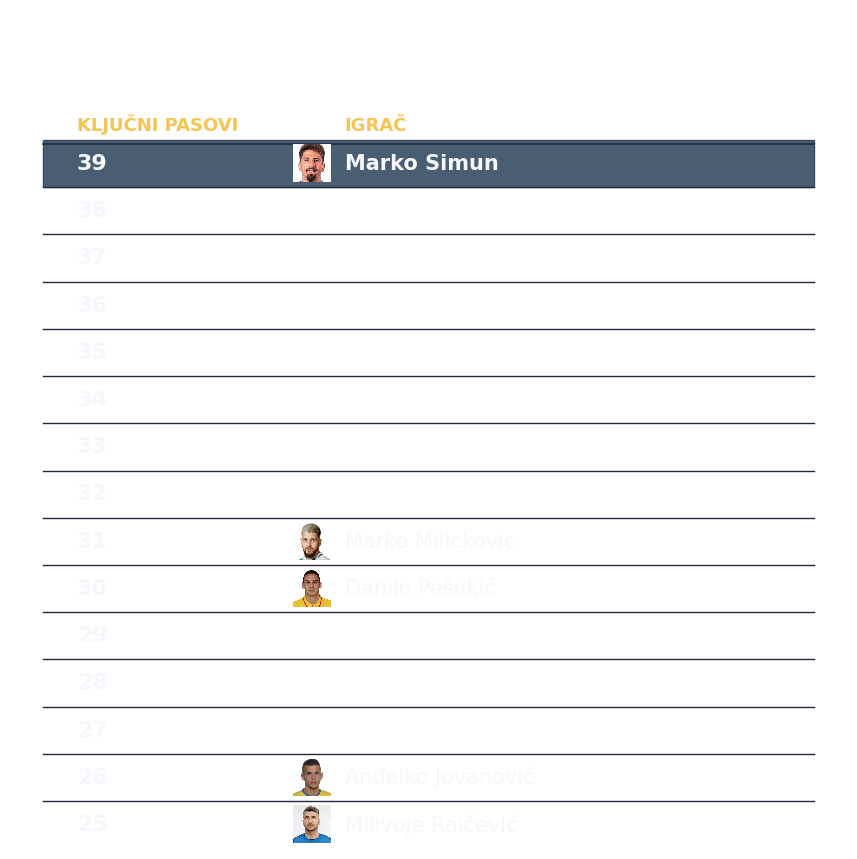

Saved chart: ..\outputs\figures\chance_creators_outlier.png


In [47]:
def add_player_photo(ax, player_id, x_ax, y_ax, zoom=0.036):
    photo_path = PLAYER_PHOTOS_DIR / f'{int(player_id)}.png'
    if not photo_path.exists():
        return
    try:
        photo = np.array(Image.open(photo_path).convert('RGBA'))
        image_box = OffsetImage(photo, zoom=zoom)
        ab = AnnotationBbox(
            image_box,
            (x_ax, y_ax),
            xycoords=ax.transAxes,
            frameon=False,
            box_alignment=(0.5, 0.5),
            zorder=4
        )
        ax.add_artist(ab)
    except Exception:
        pass


if ranking.empty:
    raise ValueError('No players matched threshold/minutes filters. Lower CHANCES_THRESHOLD or MIN_MINUTES.')

# Build a strict ladder from max key passes down to threshold (inclusive).
top_value = int(ranking['key_passes'].max())
bottom_value = int(CHANCES_THRESHOLD)
ladder_values = list(range(top_value, bottom_value - 1, -1))

# Build rows with explicit player ids so we can draw headshots.
rows = []
for value in ladder_values:
    subset = ranking[ranking['key_passes'] == value].copy()
    subset = subset.sort_values('accurate_final_third_passes', ascending=False)
    players = [
        {'player_id': int(r['player_id']), 'player_name': str(r['player_name'])}
        for _, r in subset.iterrows()
    ]
    rows.append({'value': value, 'players': players})

fig, ax = plt.subplots(figsize=(10.8, 10.8), dpi=100)
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

PHOTO_X = 0.36   # centre of player headshot
NAME_X  = 0.40   # start of player name text

# Two distinct column headers + separator line
ax.text(0.08, 0.855, 'KLJUČNI PASOVI', fontsize=13, fontweight='bold', color=ACCENT, ha='left')
ax.text(NAME_X, 0.855, 'IGRAČ', fontsize=13, fontweight='bold', color=ACCENT, ha='left')
ax.plot([0.04, 0.96], [0.838, 0.838], color=LINE_COLOR, linewidth=1.2)

# Dynamic spacing so all rows fit down to threshold.
n_rows = len(rows)
row_top = 0.815
row_bottom = 0.02
row_h = (row_top - row_bottom) / max(n_rows - 1, 1)

for i, row in enumerate(rows):
    y = row_top - i * row_h
    players = row['players']

    # Highlight the top-value line.
    if i == 0:
        ax.add_patch(plt.Rectangle((0.04, y - row_h / 2), 0.92, row_h, color=HIGHLIGHT, alpha=0.78, zorder=0))

    ax.text(0.08, y, f"{row['value']}", fontsize=16, fontweight='bold', color=TEXT_MAIN, va='center')

    if len(players) > 0:
        add_player_photo(ax, players[0]['player_id'], PHOTO_X, y, zoom=0.18)
        names_text = ', '.join([p['player_name'] for p in players])
        ax.text(
            NAME_X, y, names_text, fontsize=15, va='center', color=TEXT_MAIN,
            fontweight='bold' if i == 0 else 'normal'
        )

    ax.plot([0.04, 0.96], [y - row_h / 2, y - row_h / 2], color=LINE_COLOR, linewidth=1.0)

chart_path = FIGURES_DIR / 'chance_creators_outlier.png'
plt.savefig(chart_path, dpi=100, transparent=True, bbox_inches='tight', pad_inches=0.01)
plt.show()

print(f'Saved chart: {chart_path}')


Saved final post: ..\outputs\final_posts\chance_creators_outlier_post.png


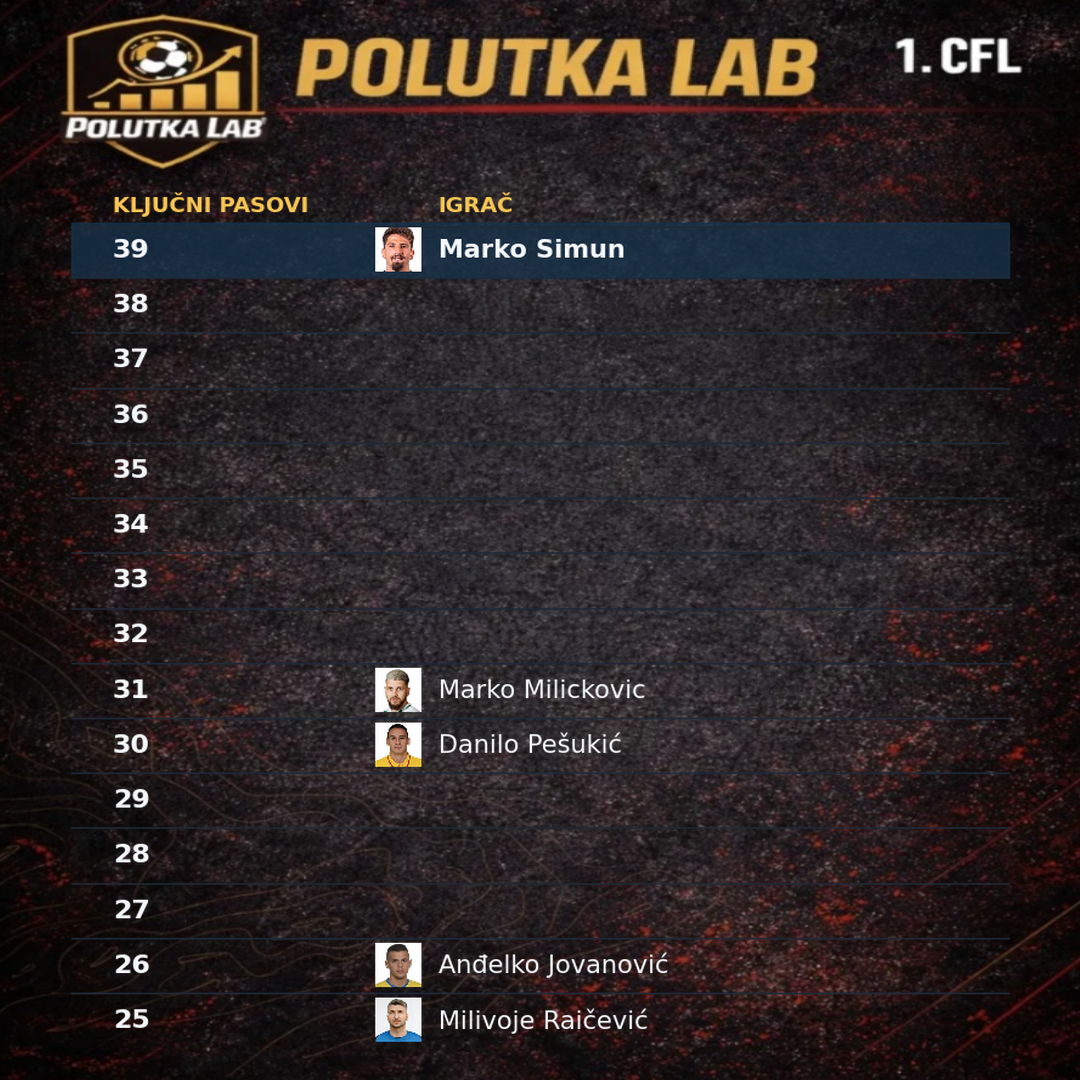

In [ ]:
# Compose final Instagram post on branded background
chart_path = FIGURES_DIR / 'chance_creators_outlier.png'
final_path = FINAL_DIR / 'chance_creators_outlier_post.png'

if not chart_path.exists():
    raise FileNotFoundError('Run the chart cell first so chance_creators_outlier.png is created.')

if BACKGROUND_PATH.exists():
    background = Image.open(BACKGROUND_PATH).convert('RGBA')
else:
    background = Image.new('RGBA', (1080, 1080), BG_COLOR)

if background.size != (1080, 1080):
    background = background.resize((1080, 1080), Image.Resampling.LANCZOS)

chart = Image.open(chart_path).convert('RGBA')
chart = chart.resize((1020, 980), Image.Resampling.LANCZOS)

# Start lower so the top-left profile logo does not collide with title text.
CHART_X, CHART_Y = 30, 70
background.alpha_composite(chart, (CHART_X, CHART_Y))


background.convert('RGB').save(final_path, quality=95)
print(f'Saved final post: {final_path}')
background